# Cartography of Guimera

This notebook visualizes the Guimera cartography for Venice’s public transport networks in two dimensions, mapping each node according to its participation coefficient and within-module degree. By classifying nodes into distinct roles, the notebook highlights the functional diversity and modular organization of the networks, helping to identify hubs, connectors, and peripheral nodes within the transport system.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import pandas as pd
from collections import Counter

The networks to be used are established.

In [2]:
g_files=['carnival_tourist','no_carnival_tourist','carnival_residents','no_carnival_residents']

Subsequently, the function that determines whether a node belongs to a role is defined. This function is necessary to delineate the boundaries of each role. The function that will represent the graphs is also defined.

In [3]:
h=0.005

cmap_light = ListedColormap(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF', '#0F0F0F', '#000FFF', '#FF00FF', '#00FFFF'])
labels = ['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7']

def my_classifier(p,z):
    """
    This is a classification function of the guimera mapping that classifies based on x[0] and x[1], which are Participation coefficient and Within-module degree.
    :param p: Participation coefficient
    :type p: float
    :param z: Within-module degree
    :type z: float
    :return: void
    :rtype: None
    """
    
    if z>=2.5:
        if p<0.31:
            return 5
        elif p<0.75:
            return 6
        else:
            return 7
            #HUB
    else:
        if p<0.05:
            return 1
        elif p<0.625:
            return 2
        elif p<0.8:
            return 3
        else:
            return 4

def plot_cg(dZ,dP):
    # We draw the decision boundary. To do this, we will assign a color to each point in the grid [x_min, x_max]x[y_min, y_max].
    x_min, x_max = 0,1
    y_min, y_max = -2, 8
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = np.array([my_classifier(x,y) for x,y in np.c_[xx.ravel(), yy.ravel()]])
    
    # We put the result in a color grid.
    Z = Z.reshape(xx.shape)
    plt.figure()
    c=plt.pcolormesh(xx, yy, Z, cmap=cmap_light)
    
    plt.xlim(xx.min(), xx.max())
    plt.xlabel("Participation coefficient, P")
    plt.xticks(np.linspace(0,1,11))
    plt.ylim(yy.min(), yy.max())
    
    plt.ylabel("Within-module degree, Z")
    plt.yticks(np.linspace(-2,8,11))
    plt.title("Role Map")
    lpatch=list()
    for i in range(7):
        lpatch.append( mpatches.Patch(color=c.cmap(1/7*i+0.01), label=labels[i]))
    
    # Add caption
    plt.legend(handles=lpatch,bbox_to_anchor=(1.05, 1), loc='upper left')
    for i in dZ:
        plt.plot(dP[i],dZ[i],color='black',marker='o')
    
    plt.show()


## Single Execution

The previously defined list of nodes is displayed.

Complex network:  carnival_tourist


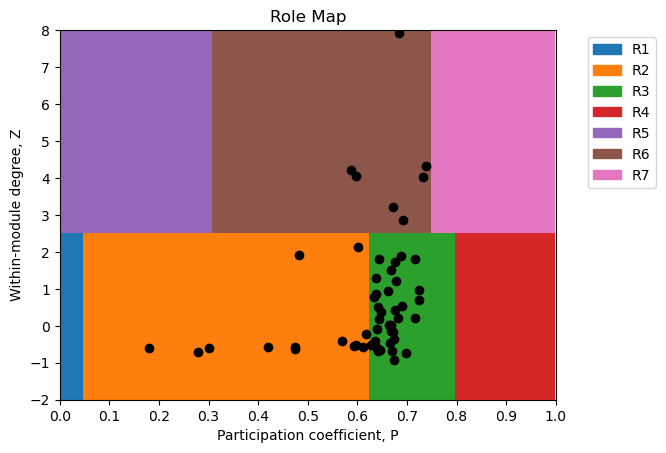

Complex network:  no_carnival_tourist


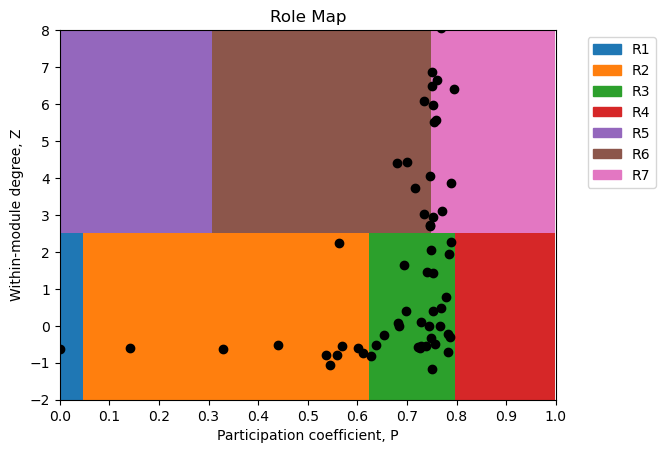

Complex network:  carnival_residents


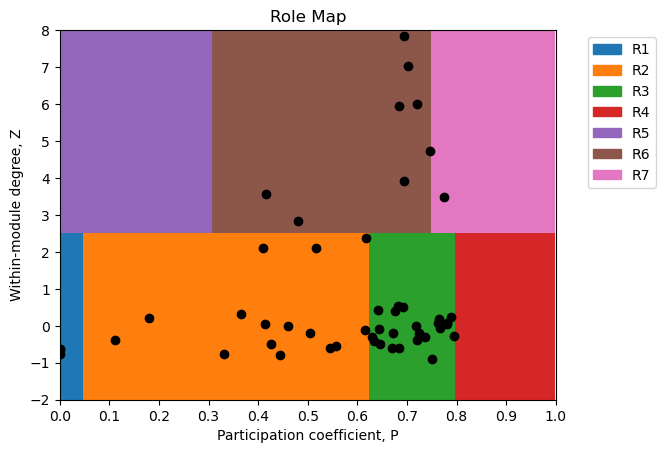

Complex network:  no_carnival_residents


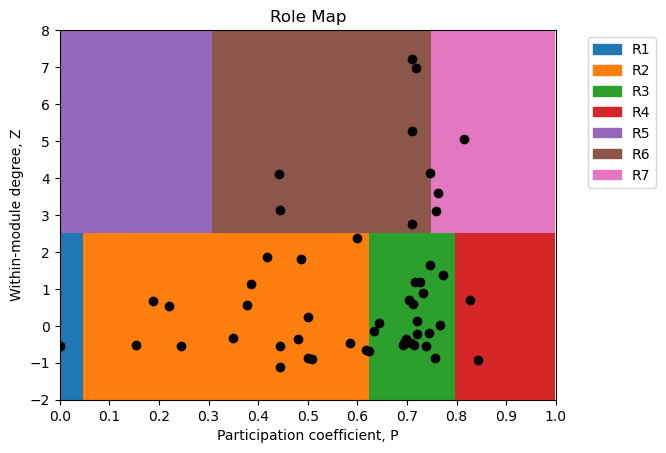

In [4]:
for i in g_files:
    print("Complex network: ",i)
    with open("../models/"+i+'_z.pickle', 'rb') as handle:
        dZ = pickle.load(handle)
    with open("../models/"+i+'_p.pickle', 'rb') as handle:
        dP = pickle.load(handle)
    plot_cg(dZ,dP)

### Distribution of % of roles

In [5]:
def plot_pct_roles(residents_pct, tourist_pct):    # Create bar plot
    labels_residents = list(residents_pct.keys())
    values_residents = list(residents_pct.values())
    labels_tourist = list(tourist_pct.keys())
    values_tourist = list(tourist_pct.values())

    # Ensure both have the same order and all roles are present
    all_labels = sorted(set(labels_residents) | set(labels_tourist))  # Sort alphabetically for string keys
    values_residents = [residents_pct.get(label, 0) for label in all_labels]
    values_tourist = [tourist_pct.get(label, 0) for label in all_labels]

    x = np.arange(len(all_labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, values_residents, width, label='Residents')
    bars2 = ax.bar(x + width/2, values_tourist, width, label='Tourist')

    ax.set_xlabel('Roles')
    ax.set_ylabel('Percentage (%)')
    ax.set_title('Role Distribution Comparison: Residents vs Tourist')
    ax.set_xticks(x)
    ax.set_xticklabels(all_labels)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [6]:
def count_roles(role_dict):
    """
    Count the frequency of each value in a dictionary.
    :param role_dict: dict with node:role pairs
    :return: Counter with frequency of each role
    """
    return Counter(role_dict.values())

def calculate_percentages(residents_rol, tourists_rol):
    
    residents_counts = count_roles(residents_rol)
    tourist_counts = count_roles(tourists_rol)

    # Calculate percentages
    total_residents = sum(residents_counts.values())
    total_tourist = sum(tourist_counts.values())

    residents_pct = {k: (v/total_residents)*100 for k, v in residents_counts.items()}
    tourist_pct = {k: (v/total_tourist)*100 for k, v in tourist_counts.items()}

    return residents_pct, tourist_pct


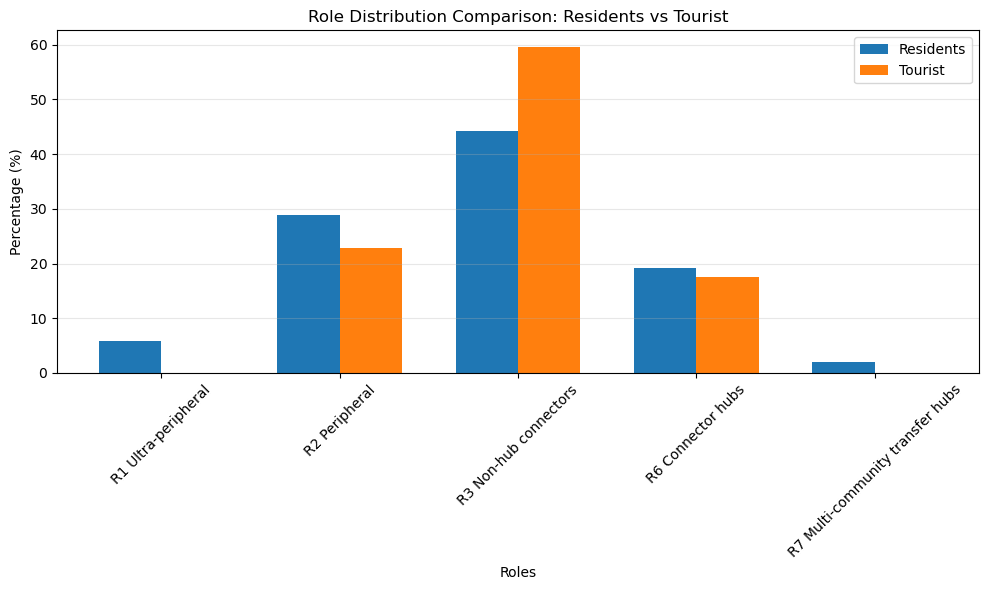

In [7]:
# Load the role data from pickle files
with open("../models/carnival_residents_rol.pickle", 'rb') as handle:
    carnival_residents_rol = pickle.load(handle)
with open("../models/carnival_tourist_rol.pickle", 'rb') as handle:
    carnival_tourist_rol = pickle.load(handle)

residents_pct, tourist_pct = calculate_percentages(carnival_residents_rol, carnival_tourist_rol)

plot_pct_roles(residents_pct, tourist_pct)


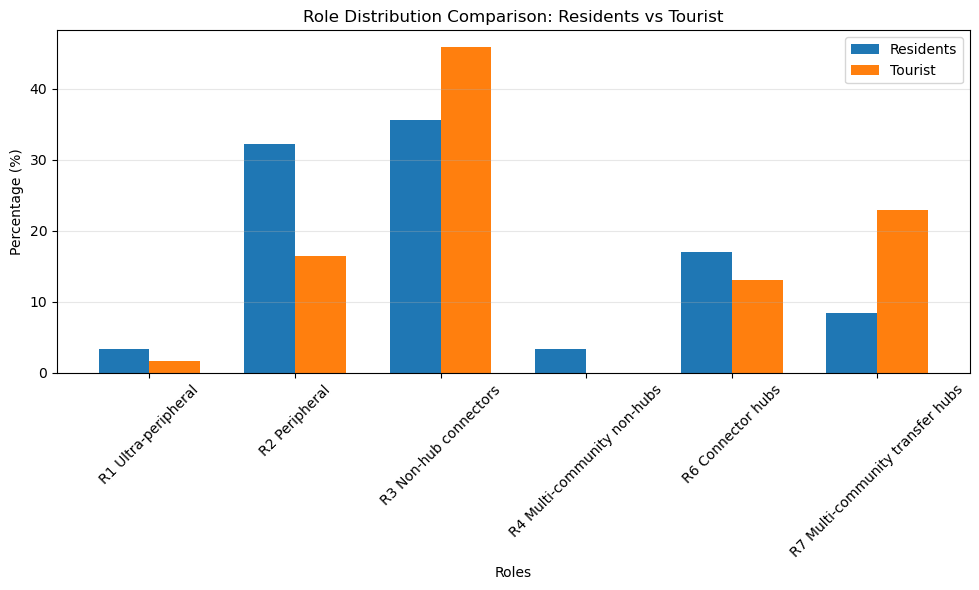

In [8]:
# Load the role data from pickle files for non-carnival period
with open("../models/no_carnival_residents_rol.pickle", 'rb') as handle:
    no_carnival_residents_rol = pickle.load(handle)
with open("../models/no_carnival_tourist_rol.pickle", 'rb') as handle:
    no_carnival_tourist_rol = pickle.load(handle)

residents_pct, tourist_pct = calculate_percentages(no_carnival_residents_rol, no_carnival_tourist_rol)

plot_pct_roles(residents_pct, tourist_pct)


## Repetitions Experiment

We show also the z and P for the selected experiment among the repetitions for the comunity detection and participation coeficients. We have selected one among those with lower hamming distance with the most voted.

Complex network:  carnival_tourist


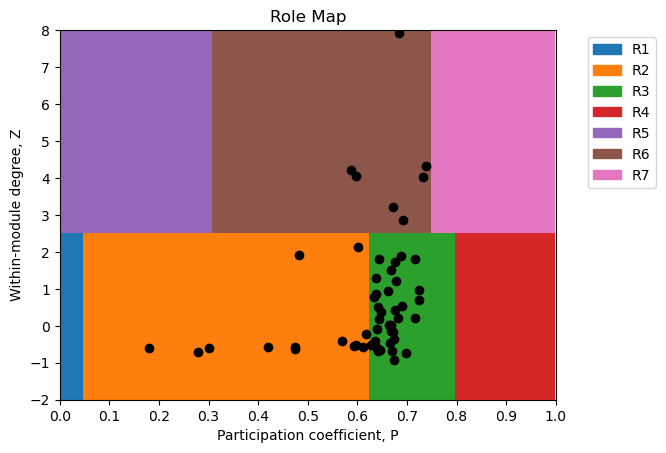

Complex network:  no_carnival_tourist


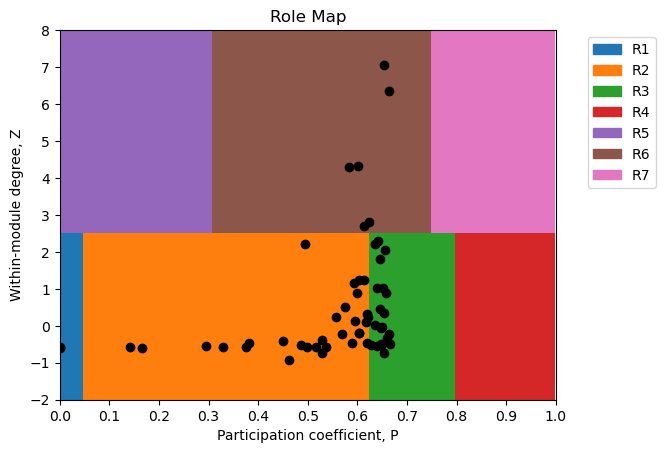

Complex network:  carnival_residents


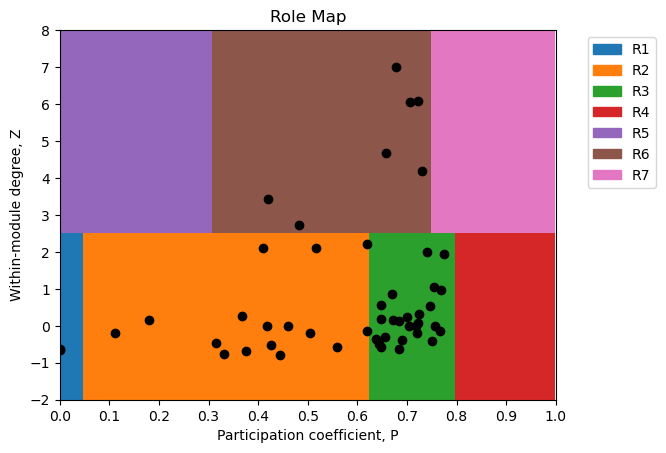

Complex network:  no_carnival_residents


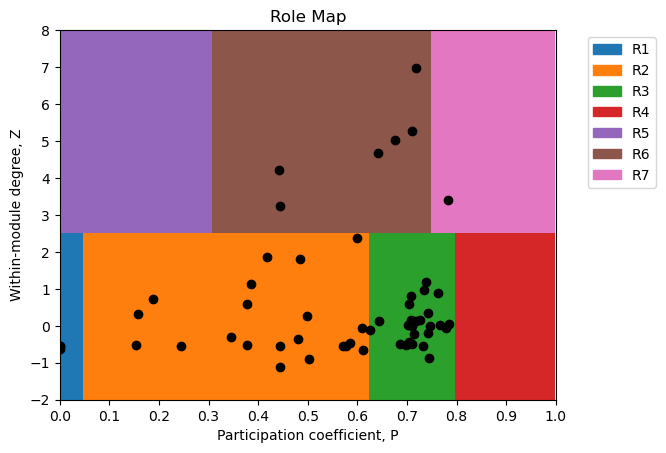

In [10]:
for i in g_files:
    print("Complex network: ", i)
    # Load mean z and p values from CSVs
    df_z = pd.read_csv(f"../models/{i}_guimera_repeated_z_final.csv", index_col=0)
    df_p = pd.read_csv(f"../models/{i}_guimera_repeated_p_final.csv", index_col=0)
    # Convert to dictionaries for compatibility with plot_cg
    dZ = df_z.iloc[:,0].to_dict()
    dP = df_p.iloc[:,0].to_dict()
    plot_cg(dZ, dP)

### Distribution of % of Roles

In [ ]:
# Unpack list if the first column contains lists with a single element
def unpack_single_element_lists(df):
    col = df.columns[0]
    if df[col].apply(lambda x: isinstance(x, str) and x.startswith('[') and x.endswith(']')).all():
        # Convert string representation of list to actual list and unpack
        df[col] = df[col].apply(lambda x: eval(x)[0] if isinstance(eval(x), list) and len(eval(x)) == 1 else x)
    return df

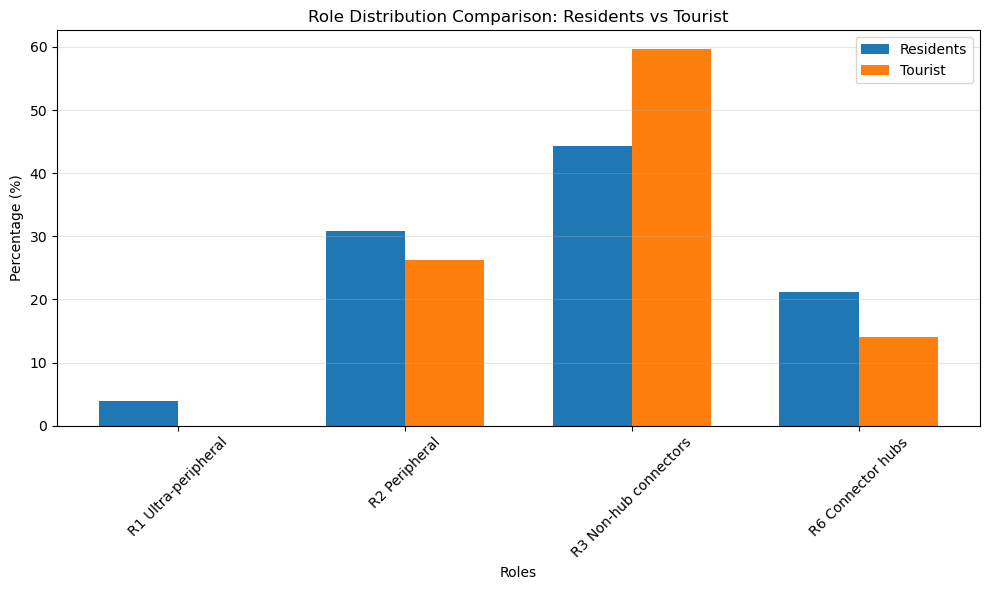

In [ ]:
# Load summarized role data for carnival period (repetitions) from CSV
import pandas as pd

residents_df = pd.read_csv("../models/carnival_residents_guimera_repeated_role_majority_vote.csv", index_col=0)
tourist_df = pd.read_csv("../models/carnival_tourist_guimera_repeated_role_majority_vote.csv", index_col=0)

residents_df = unpack_single_element_lists(residents_df)
tourist_df = unpack_single_element_lists(tourist_df)

residents_roles = residents_df['0'].to_dict()
tourist_roles = tourist_df['0'].to_dict()

residents_pct, tourist_pct = calculate_percentages(residents_roles, tourist_roles)

plot_pct_roles(residents_pct, tourist_pct)

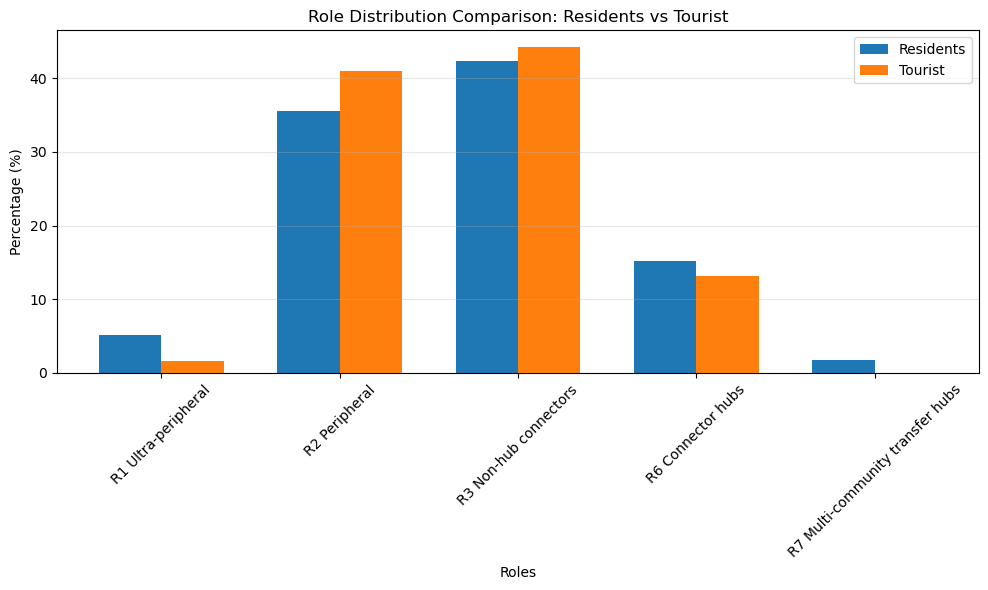

In [ ]:
# Load summarized role data for regular period (repetitions) from CSV
import pandas as pd

residents_df = pd.read_csv("../models/no_carnival_residents_guimera_repeated_role_majority_vote.csv", index_col=0)
tourist_df = pd.read_csv("../models/no_carnival_tourist_guimera_repeated_role_majority_vote.csv", index_col=0)

residents_df = unpack_single_element_lists(residents_df)
tourist_df = unpack_single_element_lists(tourist_df)

residents_roles = residents_df['0'].to_dict()
tourist_roles = tourist_df['0'].to_dict()

residents_pct, tourist_pct = calculate_percentages(residents_roles, tourist_roles)

plot_pct_roles(residents_pct, tourist_pct)

## Distribution of Roles per Community

In [ ]:
for profile in g_files:
    print(f"\n=== Profile: {profile} ===")
    # Load the community membership data
    cm_df = pd.read_csv(f"../models/{profile}_guimera_repeated_cm_final.csv", index_col=0)

    # Load the role data to get node types
    role_df = pd.read_csv(f"../models/{profile}_guimera_repeated_role_final.csv", index_col=0)

    # Get unique communities
    communities = cm_df.iloc[:, 0].unique()
    print(f"Total communities found: {len(communities)}\n")

    # For each community, get the distribution of node types
    for community in sorted(communities):
        # Get nodes in this community
        nodes_in_community = cm_df[cm_df.iloc[:, 0] == community].index.tolist()

        print(f"Community {community}:")
        print(f"  Number of stops: {len(nodes_in_community)}")

        # Get roles for nodes in this community
        community_roles = role_df.loc[nodes_in_community]

        # Count and print role distribution
        print(community_roles.iloc[:, 0].value_counts().sort_index())


=== Profile: carnival_tourist ===
Total communities found: 4

Community 0:
  Number of stops: 11
repeat_0
R3 Non-hub connectors    7
R6 Connector hubs        4
Name: count, dtype: int64
Community 1:
  Number of stops: 14
repeat_0
R2 Peripheral             3
R3 Non-hub connectors    10
R6 Connector hubs         1
Name: count, dtype: int64
Community 2:
  Number of stops: 17
repeat_0
R2 Peripheral             1
R3 Non-hub connectors    13
R6 Connector hubs         3
Name: count, dtype: int64
Community 3:
  Number of stops: 15
repeat_0
R2 Peripheral            9
R3 Non-hub connectors    4
R6 Connector hubs        2
Name: count, dtype: int64

=== Profile: no_carnival_tourist ===
Total communities found: 3

Community 0:
  Number of stops: 26
repeat_4
R1 Ultra-peripheral       1
R2 Peripheral            12
R3 Non-hub connectors    10
R6 Connector hubs         3
Name: count, dtype: int64
Community 1:
  Number of stops: 20
repeat_4
R2 Peripheral            11
R3 Non-hub connectors     6
R6 Con